# Recipe 5 — Put a view on a factor

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/recipes/r5_factor_views.ipynb)

Equities return five percent, credit has a fatter left tail, equities and real rates move the other way: a view on a driver, not on sixty-eight funds.

<a id="toc"></a>
## Contents

| | |
|---|---|
| **[1. The base](#s1)** | eight funds, six factors, nothing imposed |
| **[2. How a view reaches an asset](#s2)** | through the betas |
| **[3. What you give](#s3)** | the factors sheet |
| **[4. What it does to the assets](#s4)** | one line per beta |
| **[5. Check](#s5)** | the factor moments in the scenarios |
| **[6. A correlation between two factors](#s6)** | the factor_corr sheet |
| **[7. What is refused](#s7)** | a view an asset target cannot hold |
| **[Where to look next](#next)** | the other recipes and the derivations |

---

<a id="s1"></a>
## 1. The base

<sub>[back to contents](#toc)</sub>

Eight funds, six factors, nothing imposed.

The base is `examples/inputs/recipe_base.xlsx`: eight funds, six factors, and
not one number imposed. Every mean, volatility, shape and beta below comes
from the monthly histories since June 2007.

`tags` says which factors each class may load on. `fit` means regressed, an
empty cell means a beta of zero, and the four other sheets are empty.

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_universe.csv: 232 months, 2007-06 to 2026-09
factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
FactorMarket(8 assets on 6 factors, generator='fleishman', 0 assets without history, 0 factors without history)


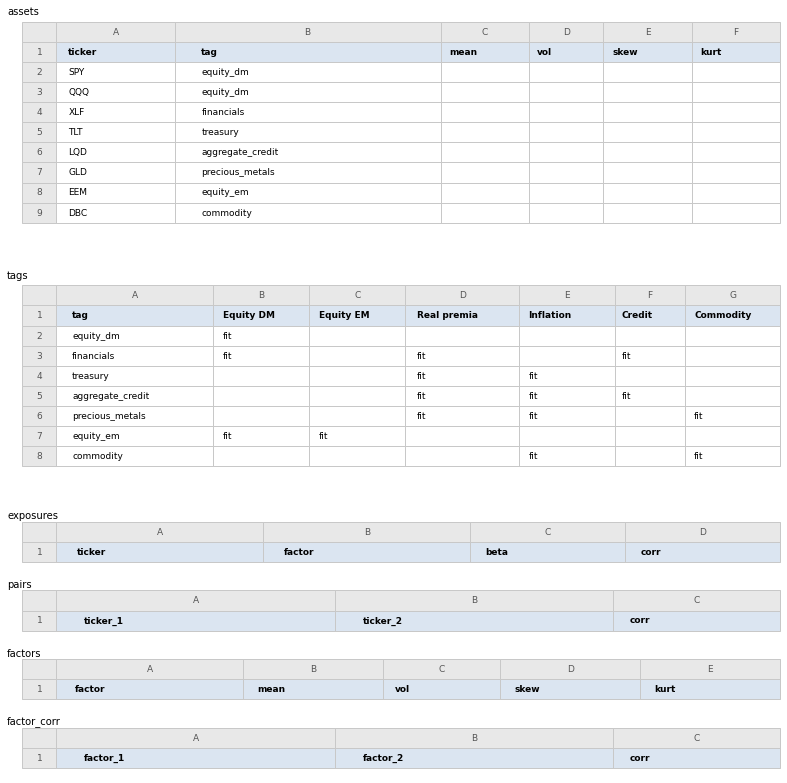

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 200)

ROOT = os.getcwd()                                   # the repo root, from wherever the notebook is opened
while not os.path.isdir(os.path.join(ROOT, "cvinemarketgen")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
try:
    import cvinemarketgen
except ImportError:                                  # Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mamadouyamar/CVineMarketGen.git", "openpyxl"], check=True)
    import cvinemarketgen
from cvinemarketgen import load_etf_monthly, load_factor_data, MarketSpec, FactorMarket, show_workbook, show_change, show_sheet

FACTORS = ["Equity DM", "Equity EM", "Real premia", "Inflation", "Credit", "Commodity"]
A = lambda m: m * 1200                               # monthly mean -> percent a year
V = lambda v: v * np.sqrt(12) * 100                  # monthly vol  -> percent a year
spec = MarketSpec.read(os.path.join(ROOT, "examples", "inputs", "recipe_base.xlsx"))
tick = list(spec.assets["ticker"])
R = load_etf_monthly(tick, start="2007-04", cache=os.path.join(ROOT, "data", "etf_cache_universe.csv"))[tick]
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv"))[FACTORS]
idx = R.index.intersection(F.index); R, F = R.loc[idx], F.loc[idx]
sim = FactorMarket(R, F, spec, generator="fleishman").fit()
print(sim)
show_workbook(spec, max_rows=8)

Eight assets on six factors, all from the histories. The generator is
Fleishman, which fits in a second; notebook 03 uses the C-vine, which takes
the tail dependence of the factors with it.

---

<a id="s2"></a>
## 2. How a view reaches an asset

<sub>[back to contents](#toc)</sub>

Through the betas.

The `factors` sheet sets the targets of the generator: what the factors' own
moments are before any asset is fitted. An asset's mean and variance follow,

$$
m_j = \alpha_j + \boldsymbol\beta_j' \boldsymbol\mu_f ,
\qquad
\sigma_j^2 = \boldsymbol\beta_j' \boldsymbol\Sigma_f \boldsymbol\beta_j + \sigma_{e,j}^2 ,
$$

so a change $\Delta \mu_k$ in one factor's mean moves asset $j$ by
$\beta_{jk}\, \Delta \mu_k$ and leaves the others where they were. The alpha
and the residual are estimated from the history and do not move with the view.

---

<a id="s3"></a>
## 3. What you give

<sub>[back to contents](#toc)</sub>

The factors sheet.

Five percent a year on Equity DM with an 18 percent volatility, and a fatter
left tail on Credit.

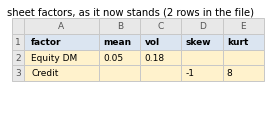

In [2]:
views = [{"factor": "Equity DM", "mean": 0.05, "vol": 0.18}, {"factor": "Credit", "skew": -1.0, "kurt": 8.0}]
spec_5 = spec
for v_ in views:
    spec_5 = spec_5.add("factors", v_)
show_change(spec_5, "factors", views)

The sheet was empty, so a factor missing from it is entirely the history's. A
factor listed with some cells empty keeps the history's value for those.

In [3]:
sim_5 = sim.with_spec(spec_5)
pd.concat([pd.DataFrame({"mean (%/yr)": A(sim.targets.mean), "vol (%/yr)": V(sim.targets.vol), "skew": sim.targets.skew, "kurt": sim.targets.kurt}).round(2).add_suffix(", history"),
           pd.DataFrame({"mean (%/yr)": A(sim_5.targets.mean), "vol (%/yr)": V(sim_5.targets.vol), "skew": sim_5.targets.skew, "kurt": sim_5.targets.kurt}).round(2).add_suffix(", target")], axis=1)

,"mean (%/yr), history","vol (%/yr), history","skew, history","kurt, history","mean (%/yr), target","vol (%/yr), target","skew, target","kurt, target"
Equity DM,7.60,16.15,-0.61,4.55,5.00,18.00,-0.61,4.55
Equity EM,-1.34,10.85,0.02,2.98,-1.34,10.85,0.02,2.98
Real premia,0.77,6.31,-0.63,5.34,0.77,6.31,-0.63,5.34
Inflation,2.02,4.80,0.12,9.27,2.02,4.80,0.12,9.27
Credit,2.48,8.45,-1.86,16.71,2.48,8.45,-1.00,8.00
Commodity,2.28,19.16,-0.54,4.88,2.28,19.16,-0.54,4.88


Equity DM goes from the sample's 7.60 percent a year to 5.00, and from 16.15
percent of volatility to 18.00. Credit's skewness and kurtosis go from -1.86
and 16.71 to -1.00 and 8.00. Every cell left empty keeps the history's value,
and a factor absent from the sheet is entirely the history's.

---

<a id="s4"></a>
## 4. What it does to the assets

<sub>[back to contents](#toc)</sub>

One line per beta.

Each asset's mean moves by its Equity DM beta times the change in that factor's mean.

In [4]:
m0 = sim.model.alpha + sim.model.beta @ sim.targets.mean.loc[sim.model.factors]
m1 = sim_5.model.alpha + sim_5.model.beta @ sim_5.targets.mean.loc[sim_5.model.factors]
d_mu = sim_5.targets.mean["Equity DM"] - sim.targets.mean["Equity DM"]
pd.DataFrame({"beta on Equity DM": sim.model.beta["Equity DM"], "mean before (%/yr)": A(m0), "mean after (%/yr)": A(m1),
              "change (%/yr)": A(m1 - m0), "beta x change in the factor": A(sim.model.beta["Equity DM"] * d_mu)}).round(2)

,beta on Equity DM,mean before (%/yr),mean after (%/yr),change (%/yr),beta x change in the factor
SPY,0.93,11.37,8.95,-2.42,-2.42
QQQ,1.03,16.64,13.96,-2.68,-2.68
XLF,1.30,7.80,4.41,-3.39,-3.39
TLT,0.00,3.83,3.83,0.00,-0.00
LQD,0.00,4.28,4.28,0.00,-0.00
GLD,0.00,10.60,10.60,0.00,-0.00
EEM,1.04,6.51,3.82,-2.69,-2.69
DBC,0.00,3.71,3.71,0.00,-0.00


An asset's mean moves by its beta times the change in the factor's mean, to the
cent: XLF by -3.39 percent a year on a beta of 1.30. The four assets with no
Equity DM exposure do not move at all. That is what a view on a factor buys:
one number, and the universe reprices consistently.

---

<a id="s5"></a>
## 5. Check

<sub>[back to contents](#toc)</sub>

The factor moments in the scenarios.

The generator reproduces the targets it was given; the assets follow from them.

In [5]:
chk5 = sim_5.check(n=20000, seed=9); fac = chk5["factors"]
print("largest correlation error %.4f" % fac.attrs["max_abs_corr_error"])
pd.DataFrame({"mean asked (%/yr)": A(fac["mean target"]), "mean simulated (%/yr)": A(fac["mean simulated"]),
              "vol asked (%/yr)": V(fac["vol target"]), "vol simulated (%/yr)": V(fac["vol simulated"]),
              "skew asked": fac["skew target"], "skew simulated": fac["skew simulated"],
              "kurt asked": fac["kurt target"], "kurt simulated": fac["kurt simulated"]}).round(2)

largest correlation error 0.0067


,mean asked (%/yr),mean simulated (%/yr),vol asked (%/yr),vol simulated (%/yr),skew asked,skew simulated,kurt asked,kurt simulated
Equity DM,5.00,5.00,18.00,18.00,-0.61,-0.61,4.55,4.55
Equity EM,-1.34,-1.34,10.85,10.85,0.02,0.02,2.98,2.98
Real premia,0.77,0.77,6.31,6.31,-0.63,-0.63,5.34,5.34
Inflation,2.02,2.02,4.80,4.80,0.12,0.12,9.27,9.27
Credit,2.48,2.48,8.45,8.45,-1.00,-1.00,8.00,8.00
Commodity,2.28,2.28,19.16,19.16,-0.54,-0.54,4.88,4.88


The generator reproduces every target to the second decimal and the largest
correlation error is 0.0067. The assets inherit those moments through their
betas, with nothing else to say about them.

---

<a id="s6"></a>
## 6. A correlation between two factors

<sub>[back to contents](#toc)</sub>

The factor_corr sheet.

One row per pair, and the rest of the matrix stays the history's. The edited
matrix is projected onto the nearest positive-definite one if an edit breaks it.

In [6]:
fc_row = {"factor_1": "Equity DM", "factor_2": "Real premia", "corr": -0.30}
sim_5b = sim.with_spec(spec.add("factor_corr", fc_row))
Xb = sim_5b.simulate(20000, seed=10); fb = sim_5b.last_factors
print("corr(Equity DM, Real premia)   sample %.2f   asked %.2f   simulated %.2f"
      % (F["Equity DM"].corr(F["Real premia"]), fc_row["corr"], fb["Equity DM"].corr(fb["Real premia"])))
print("\nwhat it does to the assets, volatility in %/yr:")
print(pd.DataFrame({"base": V(sim.check(n=20000, seed=10)["assets"]["vol simulated"].astype(float)),
                    "with the edited correlation": V(sim_5b.check(Xb)["assets"]["vol simulated"].astype(float))}).round(2).to_string())

corr(Equity DM, Real premia)   sample 0.31   asked -0.30   simulated -0.31

what it does to the assets, volatility in %/yr:
      base  with the edited correlation
SPY  15.57                        15.57
QQQ  18.91                        18.91
XLF  22.47                        25.34
TLT  14.26                        14.25
LQD   8.20                         8.22
GLD  17.49                        17.50
EEM  21.09                        21.09
DBC  19.17                        19.17


The sample has Equity DM and Real premia at +0.31, the row asks for -0.30, and
the simulation gives -0.31. XLF is the only asset that moves much, 22.5 to
25.3 percent a year: it is long Equity DM and short Real premia, so the two
exposures stop cancelling.

---

<a id="s7"></a>
## 7. What is refused

<sub>[back to contents](#toc)</sub>

A view an asset target cannot hold.

A view on a factor changes what the betas alone deliver, so an asset with a
volatility of its own can become infeasible. Raising Equity DM to 40 percent
while SPY is pinned at 15 is refused.

In [7]:
try:
    sim.with_spec(spec.add("factors", {"factor": "Equity DM", "mean": 0.05, "vol": 0.40}).add("assets", {"ticker": "SPY", "vol": 0.15}))
    print("accepted")
except ValueError as err:
    print("refused:", err)

refused: asset 'SPY': the betas alone give a volatility of 37.2% a year, above the target 15.0%; largest contributors Equity DM (beta 0.93). Lower them or raise the volatility


Either the target on the asset goes, or its betas do. To change the betas, see
[recipe 1](r1_exposures.ipynb).

---

<a id="next"></a>
## Where to look next

<sub>[back to contents](#toc)</sub>

The whole universe in one file, fitted, checked and written out:
[notebook 03](../03_many_assets_factors.ipynb). The derivations, the feasible
shapes and the bounds: the methods note, `docs/methods-note.pdf`.

The other levers:

- [what an asset loads on](r1_exposures.ipynb)
- [a fund with no history](r2_asset_without_history.ipynb)
- [an asset's mean, volatility and shape](r3_asset_targets.ipynb)
- [a correlation between two assets](r4_pair_correlation.ipynb)
- [a factor with no history](r6_factor_without_history.ipynb)